<a href="https://colab.research.google.com/github/MehulShukla-git/Movie_Recommendation_System/blob/main/Hierarchical_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Hierarchical Clustering**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/drive/MyDrive/movies_metadata.csv',
                 sep=',',
                 engine='python',
                 on_bad_lines='skip')

print(df.columns)

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')


In [4]:
df = df[['title','overview','genres','tagline','vote_average','popularity']]

df = df.dropna(subset=['title'])

df['overview'] = df['overview'].fillna('')
df['tagline'] = df['tagline'].fillna('')

In [5]:
import ast

def extract_genres(x):
    try:
        return " ".join([i['name'] for i in ast.literal_eval(x)])
    except:
        return ""

df['genres'] = df['genres'].apply(extract_genres)

df['tags'] = df['overview'] + " " + df['genres'] + " " + df['tagline']

In [6]:
import nltk, re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

df['tags'] = df['tags'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

tfidf = TfidfVectorizer(max_features=2000)

X = tfidf.fit_transform(df['tags'])

X_dense = X.toarray()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(X_dense)

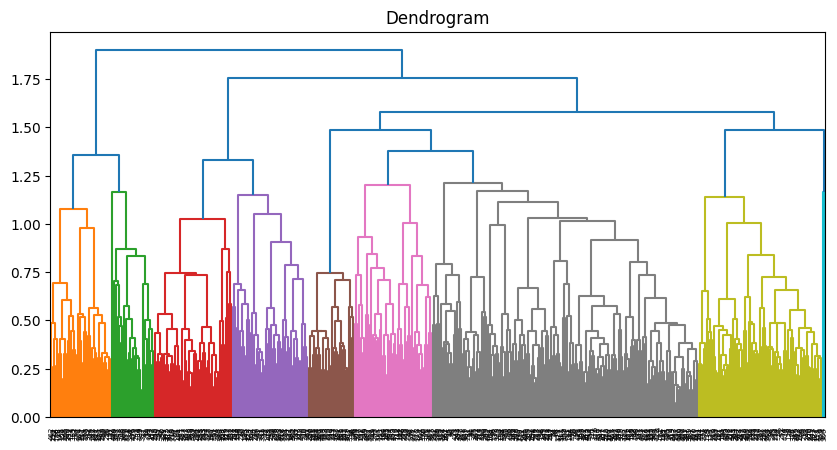

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage

sample = X_reduced[:500]

linked = linkage(sample, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [9]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=10)

df_sample = df.iloc[:len(sample)]

df_sample['cluster'] = hc.fit_predict(sample)

print("Clustering Done ")

Clustering Done 


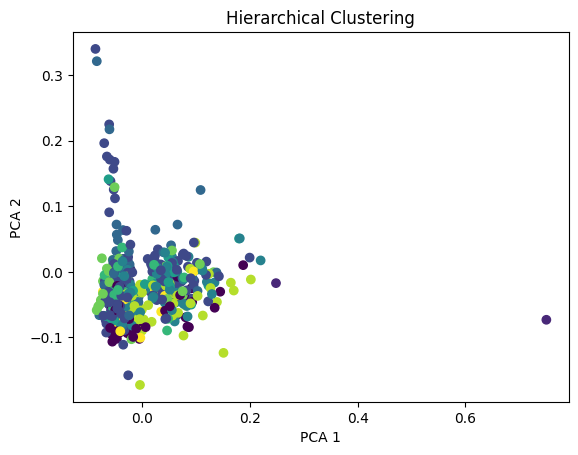

In [10]:
plt.figure()
plt.scatter(sample[:,0], sample[:,1], c=df_sample['cluster'])
plt.title("Hierarchical Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [11]:
from sklearn.metrics import silhouette_score

score = silhouette_score(sample, df_sample['cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.02133014086345708
